# Campaign impact: did the direct-mail campaigns change how much households spend?

30 campaigns (Types A, B and C) went to 1,584 of the 2,500 households. Here I use **difference-in-differences** to estimate how much extra each campaign type made targeted households spend.

**The idea.** For each campaign I compare two changes in weekly spend, from the 8 weeks *before* the campaign to the weeks *during* it:

> effect = (targeted households: during − before) − (similar households who never got any campaign: during − before)

- The *before* period removes the fact that targeted households already spent more. The retailer probably picked its better customers.
- The comparison group removes anything that changed for everyone at the same time, like seasons and holidays.

**The assumption, in plain words:** without the campaign, both groups' spending would have moved in parallel. I can't prove that directly, but I check it before the campaign started (the pre-trend check below).

**Making the comparison fair.** I only compare households with others who spent a similar amount *historically*, grouped into spend deciles. I measure that history on a separate stretch of time that ends 16 weeks before the campaign, never on the 8 weeks I use for "before". If I matched on "before" itself, a normally light shopper who happened to have a big 8 weeks would sit next to genuine heavy shoppers, then drift back down during the campaign (regression to the mean). That would make every campaign look better than it is. Households who didn't shop at all in the 8 weeks before a campaign are left out of that campaign.

In [ ]:
import os
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
from sqlalchemy import create_engine, URL

password = os.environ.get("PG_PASSWORD") or getpass("PostgreSQL password: ")
engine = create_engine(URL.create("postgresql+psycopg2", username="postgres", password=password,
                                  host="localhost", port=5432, database="retail_promo"))

baskets   = pd.read_sql("SELECT household_key, day, basket_value FROM clean.baskets", engine)
campaigns = pd.read_sql("SELECT campaign, campaign_type, start_day, end_day FROM clean.campaigns", engine)
targets   = pd.read_sql("SELECT household_key, campaign FROM raw.campaign_table", engine)
redeemed  = pd.read_sql("SELECT DISTINCT household_key, campaign FROM raw.coupon_redempt", engine)

all_households = baskets["household_key"].unique()
never_targeted = np.setdiff1d(all_households, targets["household_key"].unique())
print(f"{len(baskets):,} shopping trips, {len(all_households):,} households, "
      f"{len(never_targeted):,} never received a campaign")

251,063 shopping trips, 2,500 households, 916 never received a campaign


In [ ]:
# same chart style as the uplift notebook
BLUE, ORANGE, AQUA, GREY, INK, MUTED, SURFACE = "#2a78d6", "#eb6834", "#1baf7a", "#a3a29c", "#0b0b0b", "#52514e", "#fcfcfb"
TYPE_COLORS = {"TypeA": BLUE, "TypeB": ORANGE, "TypeC": AQUA}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d6d5d0", "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e9e8e4", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
os.makedirs("../docs/charts", exist_ok=True)

## 1. The campaigns at a glance

**Response rate** = the share of targeted households that redeemed at least one coupon from that campaign.

In [ ]:
reach = targets.groupby("campaign").size().rename("households_targeted")
responded = (targets.merge(redeemed, on=["household_key", "campaign"])
                    .groupby("campaign").size().rename("households_redeemed"))
camp = campaigns.join(reach, on="campaign").join(responded, on="campaign").fillna({"households_redeemed": 0})
camp["length_weeks"] = (camp["end_day"].clip(upper=711) - camp["start_day"] + 1) / 7

overview = camp.groupby("campaign_type").agg(
    campaigns=("campaign", "count"),
    avg_households=("households_targeted", "mean"),
    avg_length_weeks=("length_weeks", "mean"),
    households_targeted=("households_targeted", "sum"),
    households_redeemed=("households_redeemed", "sum"),
)
overview["response_rate"] = overview["households_redeemed"] / overview["households_targeted"]
overview.round(2)

,campaigns,avg_households,avg_length_weeks,households_targeted,households_redeemed,response_rate
campaign_type,,,,,,
TypeA,5,795.80,6.89,3979,635,0.16
TypeB,19,139.74,5.46,2655,210,0.08
TypeC,6,95.67,10.79,574,44,0.08


## 2. Before vs during, for every campaign

For each campaign:
- **before** = average weekly spend in the 8 weeks before it started
- **during** = average weekly spend while it ran (cut off at day 711, where the data ends)
- **earlier** = average weekly spend in the 8 weeks before *that*, which I use for the pre-trend check
- **history** = average weekly spend from day 1 up to 16 weeks before the campaign, which I use only for matching

Weeks with no shopping count as $0.

In [ ]:
day = baskets["day"].to_numpy()
hh = baskets["household_key"].to_numpy()
value = baskets["basket_value"].to_numpy()

def weekly_spend(start, end):
    """Average weekly spend per household between two days (inclusive). Households with no trips get 0."""
    mask = (day >= start) & (day <= end)
    total = pd.Series(value[mask]).groupby(hh[mask]).sum()
    return total.reindex(all_households, fill_value=0) / ((end - start + 1) / 7)

# every household's campaign windows, so I can tell who was "busy" with a campaign when
windows = targets.merge(camp[["campaign", "start_day", "end_day"]], on="campaign")
ever_targeted = windows["household_key"].unique()

def build_panel(comparison):
    """comparison = 'never' (households that never got any campaign) or
    'other_times' (households targeted by the retailer, but with nothing running for them
    from 16 weeks before this campaign until it ends)."""
    rows = []
    for c in camp.itertuples():
        end = min(c.end_day, 711)
        before  = weekly_spend(c.start_day - 56,  c.start_day - 1)
        earlier = weekly_spend(c.start_day - 112, c.start_day - 57)
        during  = weekly_spend(c.start_day, end)
        history = weekly_spend(1, c.start_day - 113)
        treated = set(targets.loc[targets["campaign"] == c.campaign, "household_key"])
        if comparison == "never":
            control = set(never_targeted)
        else:
            busy = windows.loc[(windows["start_day"] <= end) & (windows["end_day"] >= c.start_day - 112), "household_key"]
            control = set(ever_targeted) - set(busy) - treated
        shopped_before = set(before[before > 0].index)          # active in the 8 weeks before

        for group, members in [(1, treated), (0, control)]:
            members = sorted(members & shopped_before)
            rows.append(pd.DataFrame({
                "campaign": c.campaign, "campaign_type": c.campaign_type, "treated": group,
                "household_key": members, "weeks": (end - c.start_day + 1) / 7,
                "history": history[members].values, "earlier": earlier[members].values,
                "before": before[members].values, "during": during[members].values,
            }))
    panel = pd.concat(rows, ignore_index=True)
    panel["change"] = panel["during"] - panel["before"]          # what DiD compares
    panel["pre_change"] = panel["before"] - panel["earlier"]     # for the pre-trend check
    # historical spend decile, within each campaign, so like is compared with like
    panel["spend_decile"] = panel.groupby("campaign")["history"].transform(
        lambda s: pd.qcut(s.rank(method="first"), 10, labels=False))
    return panel

panel = build_panel("never")
print(f"{len(panel):,} household-campaign rows "
      f"({panel['treated'].sum():,} targeted, {(1 - panel['treated']).sum():,} comparison)")

26,925 household-campaign rows (7,130 targeted, 19,795 comparison)


In [ ]:
# simple DiD for each campaign, with a t-test on the change
def simple_did(g):
    t, c = g[g["treated"] == 1]["change"], g[g["treated"] == 0]["change"]
    return pd.Series({
        "campaign_type": g["campaign_type"].iloc[0],
        "targeted": len(t), "comparison": len(c),
        "before_targeted": g.loc[g["treated"] == 1, "before"].mean(),
        "before_comparison": g.loc[g["treated"] == 0, "before"].mean(),
        "did_per_week": t.mean() - c.mean(),
        "p_value": stats.ttest_ind(t, c, equal_var=False).pvalue,
    })

per_campaign = panel.groupby("campaign").apply(simple_did).round(3)
per_campaign.sort_values(["campaign_type", "campaign"])

,campaign_type,targeted,comparison,before_targeted,before_comparison,did_per_week,p_value
campaign,,,,,,,
8,TypeA,1063,629,52.054,12.112,0.169,0.863
13,TypeA,1063,672,52.324,13.248,-0.350,0.717
18,TypeA,1114,675,50.449,15.282,2.485,0.009
26,TypeA,324,632,48.519,12.856,6.263,0.000
30,TypeA,352,631,51.229,10.991,-0.476,0.760
1,TypeB,13,615,41.639,11.815,11.068,0.117
2,TypeB,48,621,48.027,11.673,2.162,0.584
4,TypeB,81,626,59.814,11.785,1.454,0.654
5,TypeB,165,638,77.623,11.350,-0.909,0.751


`before_targeted` vs `before_comparison` shows why a plain "targeted vs not" comparison would mislead: targeted households were already spending more before any campaign started.

## 3. The main result: effect of each campaign type

For each type I stack all its campaigns and fit:

> change in weekly spend ~ targeted + campaign + historical spend decile

- The coefficient on `targeted` is the DiD effect: extra dollars per household per week.
- `campaign` and `historical spend decile` make sure targeted households are only compared with similar households in the same campaign.
- Standard errors are **clustered by household**, because the same household can appear in several campaigns.

`p_value` < 0.05 means the effect is unlikely to be just chance.

In [ ]:
def did_by_type(outcome, data):
    out = []
    for t, g in data.groupby("campaign_type"):
        model = smf.ols(f"{outcome} ~ treated + C(campaign) + C(spend_decile)", data=g).fit(
            cov_type="cluster", cov_kwds={"groups": g["household_key"]})
        est, se = model.params["treated"], model.bse["treated"]
        tg = g[g["treated"] == 1]
        out.append({
            "campaign_type": t,
            "campaigns": g["campaign"].nunique(),
            "targeted_households": tg["household_key"].nunique(),
            "effect_per_week": est,
            "ci95_low": est - 1.96 * se,
            "ci95_high": est + 1.96 * se,
            "p_value": model.pvalues["treated"],
            "effect_pct_of_spend": est / tg["before"].mean(),
            "total_extra_sales": est * (tg["weeks"]).sum(),   # per targeted household-week
        })
    return pd.DataFrame(out).set_index("campaign_type")

did = did_by_type("change", panel)
did.round(3)

,campaigns,targeted_households,effect_per_week,ci95_low,ci95_high,p_value,effect_pct_of_spend,total_extra_sales
campaign_type,,,,,,,,
TypeA,5,1491,2.066,0.551,3.580,0.008,0.040,57642.345
TypeB,19,1016,-0.255,-1.780,1.269,0.743,-0.004,-3537.561
TypeC,6,394,0.825,-2.208,3.858,0.594,0.011,4498.867


## 4. Pre-trend check: were the groups already moving in parallel?

Same model, but on the change from *earlier* to *before*, when no campaign was running yet. If the assumption holds, this should be close to zero and not significant.

In [ ]:
pretrend = did_by_type("pre_change", panel)[["effect_per_week", "ci95_low", "ci95_high", "p_value"]]
pretrend.columns = ["pre_trend_per_week", "ci95_low", "ci95_high", "p_value"]
pretrend.round(3)

,pre_trend_per_week,ci95_low,ci95_high,p_value
campaign_type,,,,
TypeA,-1.445,-2.845,-0.046,0.043
TypeB,-1.875,-3.924,0.174,0.073
TypeC,-5.284,-8.278,-2.289,0.001


## 4b. A closer comparison group

The households that never got a campaign spend far less than the ones the retailer targets, so even after matching they may not move in parallel. A fairer comparison: **households the retailer targeted at a different time**. Nothing was running for them from 16 weeks before this campaign until it ended. They're the same kind of customer the retailer picks, just not picked this time.

In [ ]:
panel_alt = build_panel("other_times")
print(f"{(1 - panel_alt['treated']).sum():,} comparison rows "
      f"(avg spend before: targeted ${panel_alt.loc[panel_alt.treated == 1, 'before'].mean():.2f}, "
      f"comparison ${panel_alt.loc[panel_alt.treated == 0, 'before'].mean():.2f} per week)")

did_alt = did_by_type("change", panel_alt)
pretrend_alt = did_by_type("pre_change", panel_alt)[["effect_per_week", "ci95_low", "ci95_high", "p_value"]]
pretrend_alt.columns = ["pre_trend_per_week", "ci95_low", "ci95_high", "p_value"]
display(did_alt.round(3))
display(pretrend_alt.round(3))

12,871 comparison rows (avg spend before: targeted $60.83, comparison $38.08 per week)


,campaigns,targeted_households,effect_per_week,ci95_low,ci95_high,p_value,effect_pct_of_spend,total_extra_sales
campaign_type,,,,,,,,
TypeA,5,1491,0.128,-1.416,1.671,0.871,0.002,3559.445
TypeB,19,1016,-0.792,-2.623,1.040,0.397,-0.011,-10972.293
TypeC,6,394,2.607,-1.261,6.475,0.187,0.035,14213.210


,pre_trend_per_week,ci95_low,ci95_high,p_value
campaign_type,,,,
TypeA,-1.666,-3.173,-0.158,0.030
TypeB,-4.332,-6.158,-2.506,0.000
TypeC,-5.109,-8.813,-1.405,0.007


In [ ]:
# side by side: which comparison group passes the pre-trend check?
summary = pd.DataFrame({
    "effect (never targeted)": did["effect_per_week"],
    "p (never)": did["p_value"],
    "pre-trend p (never)": pretrend["p_value"],
    "effect (targeted at other times)": did_alt["effect_per_week"],
    "p (other times)": did_alt["p_value"],
    "pre-trend p (other times)": pretrend_alt["p_value"],
}).round(3)
summary

,effect (never targeted),p (never),pre-trend p (never),effect (targeted at other times),p (other times),pre-trend p (other times)
campaign_type,,,,,,
TypeA,2.066,0.008,0.043,0.128,0.871,0.030
TypeB,-0.255,0.743,0.073,-0.792,0.397,0.000
TypeC,0.825,0.594,0.001,2.607,0.187,0.007


A pre-trend p-value above 0.05 means I can't see the groups drifting apart before the campaign, which is what I want. I use whichever comparison group passes for the main result.

## 5. Charts

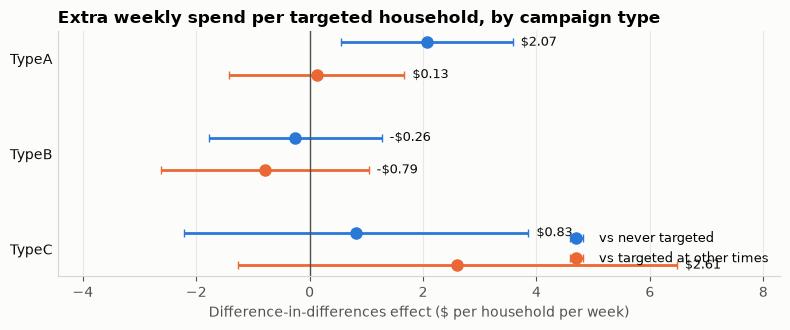

In [ ]:
# effect per week by campaign type, under both comparison groups, with 95% ranges
fig, ax = plt.subplots(figsize=(8, 3.4))
types = ["TypeA", "TypeB", "TypeC"]
for offset, (res, name, color) in zip([0.17, -0.17], [(did, "vs never targeted", BLUE),
                                                     (did_alt, "vs targeted at other times", ORANGE)]):
    r = res.loc[types]
    y = np.arange(len(types))[::-1] + offset
    ax.errorbar(r["effect_per_week"], y, xerr=[r["effect_per_week"] - r["ci95_low"], r["ci95_high"] - r["effect_per_week"]],
                fmt="o", color=color, ecolor=color, elinewidth=2, capsize=3, markersize=8, label=name)
    for yy, v, hi in zip(y, r["effect_per_week"], r["ci95_high"]):
        label = f"-${abs(v):,.2f}" if v < 0 else f"${v:,.2f}"
        ax.text(hi, yy, f"  {label}", va="center", ha="left", color=INK, fontsize=9)
ax.set_yticks(np.arange(len(types))[::-1], types)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_title("Extra weekly spend per targeted household, by campaign type")
ax.set_xlabel("Difference-in-differences effect ($ per household per week)")
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0, colors=INK)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.margins(x=0.2)
fig.tight_layout(); fig.savefig("../docs/charts/campaign_effect_by_type.png", dpi=150); plt.show()

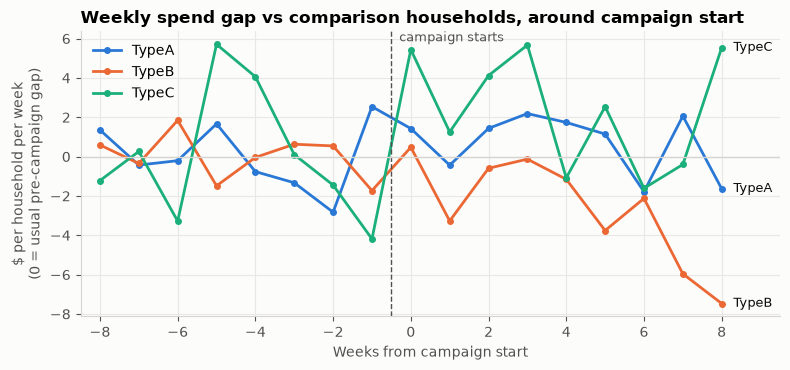

In [ ]:
# event study: gap in weekly spend (targeted minus comparison), week by week around the start
week_rows = []
for c in camp.itertuples():
    members = panel[panel["campaign"] == c.campaign]
    rel_week = (day - c.start_day) // 7
    mask = (rel_week >= -8) & (rel_week <= 8) & np.isin(hh, members["household_key"])
    wk = pd.DataFrame({"household_key": hh[mask], "rel_week": rel_week[mask], "value": value[mask]})
    wk = wk.groupby(["household_key", "rel_week"])["value"].sum().unstack(fill_value=0).reindex(
        index=members["household_key"], columns=range(-8, 9), fill_value=0)
    is_t = members.set_index("household_key")["treated"]
    gap = wk[is_t == 1].mean() - wk[is_t == 0].mean()
    week_rows.append(pd.DataFrame({"campaign_type": c.campaign_type, "rel_week": gap.index,
                                   "gap": gap.values - gap.loc[-8:-1].mean(),   # 0 = the average pre-campaign gap
                                   "weight": (is_t == 1).sum()}))
event = pd.concat(week_rows)
event = (event.assign(w_gap=event["gap"] * event["weight"]).groupby(["campaign_type", "rel_week"])
              .apply(lambda g: g["w_gap"].sum() / g["weight"].sum()).rename("gap").reset_index())

fig, ax = plt.subplots(figsize=(8, 3.8))
for t, g in event.groupby("campaign_type"):
    ax.plot(g["rel_week"], g["gap"], color=TYPE_COLORS[t], linewidth=2, marker="o", markersize=4, label=t)
    ax.text(8.3, g["gap"].iloc[-1], t, color=INK, va="center", fontsize=9)
ax.axvline(-0.5, color=MUTED, linewidth=1, linestyle="--")
ax.axhline(0, color="#d6d5d0", linewidth=1)
ax.text(-0.3, ax.get_ylim()[1], "campaign starts", color=MUTED, fontsize=9, va="top")
ax.set_title("Weekly spend gap vs comparison households, around campaign start")
ax.set_xlabel("Weeks from campaign start")
ax.set_ylabel("$ per household per week\n(0 = usual pre-campaign gap)")
ax.legend(frameon=False, loc="upper left")
ax.set_xlim(-8.5, 9.5)
fig.tight_layout(); fig.savefig("../docs/charts/campaign_event_study.png", dpi=150); plt.show()

Before week 0 the lines should hover around zero: that's the parallel-trends assumption, seen visually. If a line jumps after week 0 and stays up, that campaign type changed behaviour.

## What I found

1. **Type A campaigns reach the most households and get double the response.** An average of 796 households per campaign, and 16% of them redeemed a coupon, against 8% for Types B and C.
2. **The retailer targets its heavy shoppers.** Targeted households spent $50-90 a week before a campaign; households that never got one spent $11-17.
3. **It targets them just as their spending starts to slip.** In the 8 weeks before a campaign, targeted households' spending fell by $1.7-5.3 a week more than either comparison group's. It looks like win-back targeting.
4. **That breaks the parallel-trends assumption,** so the pre-trend check fails in both designs (only Type B vs never-targeted scrapes through, at p = 0.07).
5. **Type A's effect is somewhere between $0 and $2 per household per week.** Against never-targeted households it's +$2.07 (+4% of spend, p = 0.008); against households targeted at other times it's +$0.13 (p = 0.87).
6. **Types B and C show no measurable effect** in either comparison. Every range includes zero.
7. **Bottom line: this data can't prove the campaigns changed spending.** Targeting wasn't random, so I can't separate the campaign's effect from households bouncing back to their normal level. The only way to know is a randomised holdout: an A/B test (Phase 6).